In [45]:
# Import Libraries
import pandas as pd
import numpy as np












In [46]:
# Load Config
import yaml
with open("../config/config.yaml","r") as file:
    config = yaml.safe_load(file)

config

{'data_path': 'credit_risk.csv',
 'target_column': 'loan_status',
 'test_size': 0.2,
 'random_state': 42,
 'model': {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05},
 'model_path': 'model.pkl'}

In [29]:
df = pd.read_csv("credit_risk.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [30]:
print(df.shape)


(32581, 12)


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [33]:
df.describe()



,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [34]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [36]:
# Missing value indicators
df['emp_length_missing'] = df['person_emp_length'].isnull().astype(int)
df['interest_rate_missing'] = df['loan_int_rate'].isnull().astype(int)

# Median imputation
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [38]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
emp_length_missing            0
interest_rate_missing         0
dtype: int64

In [44]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    if col != config["target_column"]:  
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le
        target_encoder = LabelEncoder()
df[config["target_column"]] = target_encoder.fit_transform(df[config["target_column"]])

In [42]:
if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
    
    df['loan_income_ratio'] = (
        df['loan_amnt'] /
        (df['annual_inc'] + 1)
    )

In [47]:
if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
    
    df['loan_income_ratio'] = ( df['loan_amnt'] /(df['annual_inc'] + 1))

In [50]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=[config["target_column"]])
y = df[config["target_column"]]
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size=config["test_size"],random_state=config["random_state"],stratify=y)

In [51]:
train_df = pd.concat([X_train,y_train],axis=1)
test_df = pd.concat([X_test,y_test],axis=1)
train_df.to_csv("../data/processed/train.csv",index=False)
test_df.to_csv("../data/processed/test.csv",index=False)

In [54]:
# Model Training
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=config["model"]["n_estimators"],
    max_depth=config["model"]["max_depth"],
    learning_rate=config["model"]["learning_rate"],
    random_state=config["random_state"]
)

model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [59]:
# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [58]:

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
auc = roc_auc_score(y_test,y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.9357066134724566
Precision: 0.9799043062200957
Recall   : 0.720112517580872
F1 Score : 0.8301580867450344
ROC-AUC  : 0.9459761024362707


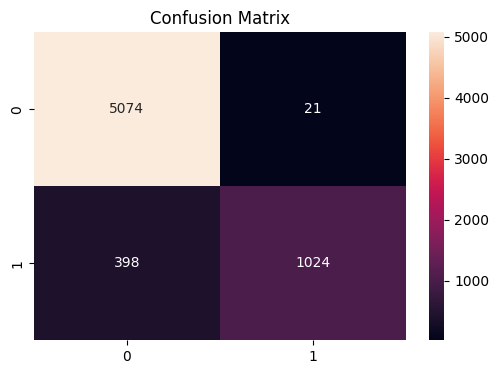

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()

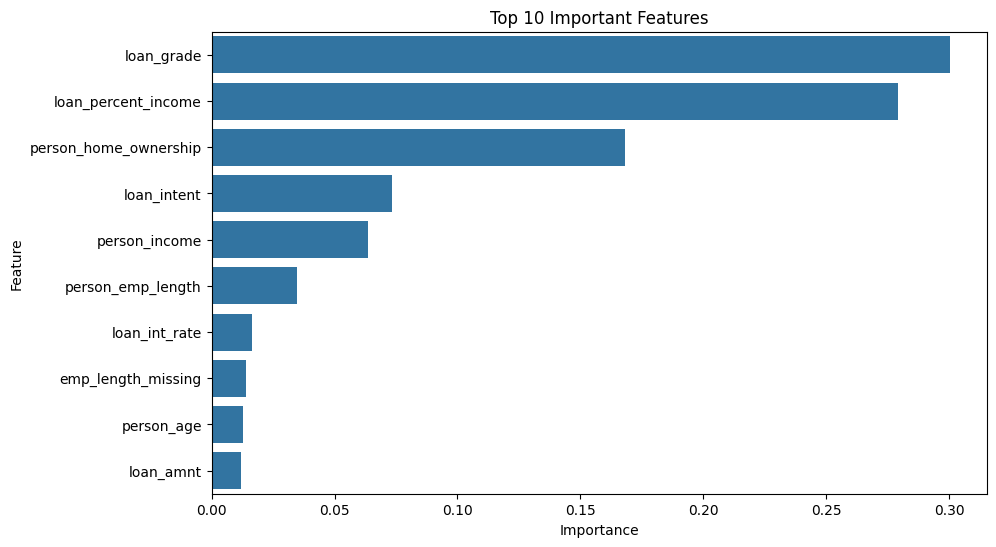

In [65]:
importance = pd.DataFrame({'Feature':X.columns,'Importance':model.feature_importances_ })
importance = importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10),x='Importance', y='Feature')
plt.title("Top 10 Important Features")
plt.show()

In [68]:
import joblib
joblib.dump(model,config["model_path"])
print("Model Saved Successfully")

Model Saved Successfully


In [69]:
loaded_model = joblib.load(config["model_path"])
sample_prediction = loaded_model.predict(X_test.iloc[:5])
print(sample_prediction)

[0 0 0 0 0]


In [71]:
import joblib

joblib.dump(model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [73]:
import joblib
import os

model_path = r"C:\Users\SOUMYOJIT\PycharmProjects\pythonProject\Credit_risk_pipeline\credit_risk_model.pkl"

joblib.dump(model, model_path)

print("Saved:", os.path.exists(model_path))
print("Size:", os.path.getsize(model_path), "bytes")

Saved: True
Size: 615341 bytes


In [74]:
loaded_model = joblib.load(model_path)
print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>
